In [24]:
from pathlib import Path
from turtle import width
import cv2

def split_mp4_to_frames(video_path: str, interval: int = 20) -> list:
    """Open an MP4 file and return all frames as a list of images (numpy arrays)."""
    path = Path(video_path)
    if not path.exists():
        raise FileNotFoundError(f"Video file not found: {path}")

    capture = cv2.VideoCapture(str(path))
    if not capture.isOpened():
        raise ValueError(f"Could not open video file: {path}")
    
    total_frames = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = capture.get(cv2.CAP_PROP_FPS)
    duration_seconds = total_frames / fps
    
    print(f"Total Frames: {total_frames}")
    print(f"FPS: {fps}")
    print(f"Duration: {duration_seconds:.2f} s")

    width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print(f"Current resolution: {width}x{height}")

    frames = []
    i = 0
    try:
        while True:
            ok, frame = capture.read()
            if not ok:
                break
            i += 1
            if i % interval == 0:
                frames.append(frame)
    finally:
        capture.release()

    return frames

# path = "ArchiveNTV/2003/1_01_01_2003_Karpova_Wasserman_Shtefan.mp4"
path = "ArchiveNTV/2003/83_06_12_2003_Prokofeva_Pristinskiy_Zhdanov.mp4"
frames = split_mp4_to_frames(path, interval=25)
print(f"Extracted: {len(frames)}")

Total Frames: 57058
FPS: 24.999745631791967
Duration: 2282.34 s
Current resolution: 302x240
Extracted: 2282


In [25]:
from sys import getsizeof
total_size = sum(getsizeof(frame) for frame in frames)
print(f"Total size of frames in memory: {total_size / (1024 * 1024):.2f} MB")

Total size of frames in memory: 473.52 MB


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

v_offset = 75
h_offset_begin = 70
h_offset_end = 100

lower_blue = np.array([100, 80, 50])
upper_blue = np.array([130, 255, 255])

def plot_frames(begin=0, end=len(frames)):
    cols = 4
    rows = (end - begin + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4 * rows))
    axes = axes.flatten()

    for i, (ax, frame) in enumerate(zip(axes, frames[begin:end])):
        ax.imshow(frame[v_offset:-v_offset, h_offset_begin:-h_offset_end])
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
        mask = cv2.inRange(hsv, lower_blue, upper_blue)

        # Считаем процент синего на экране
        blue_ratio = (cv2.countNonZero(mask) / mask.size) * 100
        ax.set_title(f'Frame {i + begin}, ratio: {blue_ratio:.2f}%', fontsize=12)
        ax.axis('off')

    for ax in axes[len(frames[begin:end]):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    #plt.imshow(frames[2005][v_offset:-v_offset, h_offset:-h_offset])

plot_frames(1800, 2000)

In [7]:
import imagehash
from PIL import Image

img1 = Image.fromarray(frames[1255])
hash1 = imagehash.phash(img1)
for i in range(1250, 1264):
    img2 = Image.fromarray(frames[i])
    # Perceptual hashes
    hash2 = imagehash.phash(img2)

    # Hamming distance between hashes
    distance = hash1 - hash2

    print(f"Distance to frame {i}:", distance)

Distance to frame 1250: 26
Distance to frame 1251: 18
Distance to frame 1252: 4
Distance to frame 1253: 0
Distance to frame 1254: 4
Distance to frame 1255: 0
Distance to frame 1256: 2
Distance to frame 1257: 28
Distance to frame 1258: 28
Distance to frame 1259: 28
Distance to frame 1260: 28
Distance to frame 1261: 34
Distance to frame 1262: 34
Distance to frame 1263: 32


In [12]:
import numpy as np

lower_blue = np.array([100, 80, 50])
upper_blue = np.array([130, 255, 255])
hsv = cv2.cvtColor(frames[1255], cv2.COLOR_BGR2HSV)
mask = cv2.inRange(hsv, lower_blue, upper_blue)
            
# Считаем процент синего на экране
blue_ratio = (cv2.countNonZero(mask) / mask.size) * 100
print(blue_ratio)

84.724609375


[2476.  214.  708.  225.  458.  396.  307.  348.  331.  319.]
[9710. 1674. 1286. 1211. 1411. 2095. 4082. 4673. 4505. 3208.]
[241997.  15417.   6737.   3569.   2074.   1451.   1146.    997.    761.
    719.]


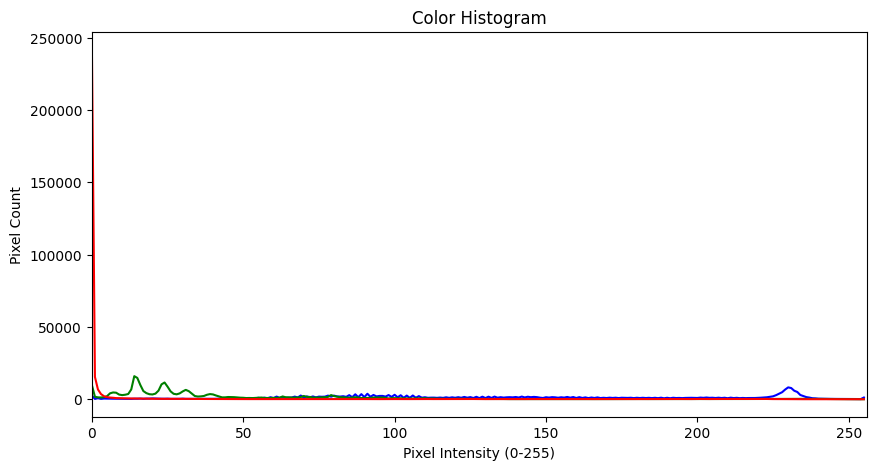

In [7]:


# 2. Define channel names and colors for plotting
colors = ('b', 'g', 'r')

# 3. Loop through channels and calculate histograms
plt.figure(figsize=(10, 5))
plt.title('Color Histogram')
plt.xlabel('Pixel Intensity (0-255)')
plt.ylabel('Pixel Count')

for i, col in enumerate(colors):
    # Calculate histogram for the current channel (i)
    hist = cv2.calcHist([frames[515]], [i], None, [256], [0, 256])
    print(hist[:10, 0])
    
    # Plot using the corresponding color
    plt.plot(hist, color=col)
    plt.xlim([0, 256])

plt.show()


In [4]:
import easyocr

reader = easyocr.Reader(['ru'])

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


In [5]:
result = reader.readtext(question)
for bbox, text, prob in result:
    print(f"Text: {text}, Confidence: {prob:.2f}")

Text: В 1602 году во Фландрии, Confidence: 0.67
Text: впервые прИМеНИЛИ (НСрЯДЫ, Confidence: 0.62
Text: именЮО € ТСКИМ (ОдерЖИМЫМ, Confidence: 0.18


/home/djoker/Jeopardy/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


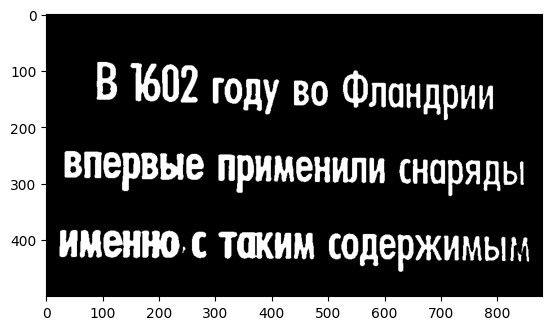

In [8]:
import cv2
import numpy as np

def preprocess_for_ocr(frame):
    if frame is None:
        raise ValueError("Input frame is None")

    # Accept both color (BGR/BGRA) and already-grayscale images.
    if len(frame.shape) == 2:
        gray = frame
    elif len(frame.shape) == 3 and frame.shape[2] == 3:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    elif len(frame.shape) == 3 and frame.shape[2] == 4:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGRA2GRAY)
    else:
        raise ValueError(f"Unsupported frame shape for OCR preprocessing: {frame.shape}")
    
    # 2. Rescale (Upscale x2) - Small text is the enemy of OCR
    # Interpolation=cv2.INTER_CUBIC is best for upscaling
    gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    
    # 3. Denoise (Remove compression grain)
    denoised = cv2.fastNlMeansDenoising(gray, h=10)
    
    # 4. Thresholding (Binarization)
    # Since questions are usually white on blue, we use Otsu's thresholding
    # to make the text purely black and background purely white.
    _, thresh = cv2.threshold(denoised, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # 5. Invert if necessary (OCR prefers Black text on White background)
    # If the text is white on black after threshold, flip it:
    # white_pixels = np.sum(thresh == 255)
    # black_pixels = np.sum(thresh == 0)
    # if white_pixels > black_pixels: thresh = cv2.bitwise_not(thresh)

    return thresh

preprocessed = preprocess_for_ocr(question)
plt.imshow(preprocessed, cmap='gray');

In [11]:
from paddleocr import PaddleOCR
import cv2

# Workaround for Paddle 3.3 CPU oneDNN/PIR runtime issue on this environment.
ocr = PaddleOCR(
    lang='ru',
    use_textline_orientation=True,
    enable_mkldnn=False,
    device='cpu',
)

# PaddleOCR expects 3-channel images in this pipeline branch.
if preprocessed.ndim == 2:
    processed_img = cv2.cvtColor(preprocessed, cv2.COLOR_GRAY2BGR)
else:
    processed_img = preprocessed

result = ocr.predict(processed_img)

# Support both old and new PaddleOCR output formats.
texts = []
if isinstance(result, list) and result and isinstance(result[0], list):
    for line in result[0]:
        if isinstance(line, (list, tuple)) and len(line) > 1 and isinstance(line[1], (list, tuple)) and line[1]:
            texts.append(str(line[1][0]))
elif isinstance(result, list) and result and isinstance(result[0], dict):
    rec_texts = result[0].get('rec_texts', [])
    texts = [str(t) for t in rec_texts]

question_text = " ".join(texts)
print(question_text)

Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/djoker/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/djoker/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/djoker/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/djoker/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('eslav_PP-OCRv5_mobile_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: 

В 602 году во Фландрии впервые применили снаряды именнос таким содержимым
